YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


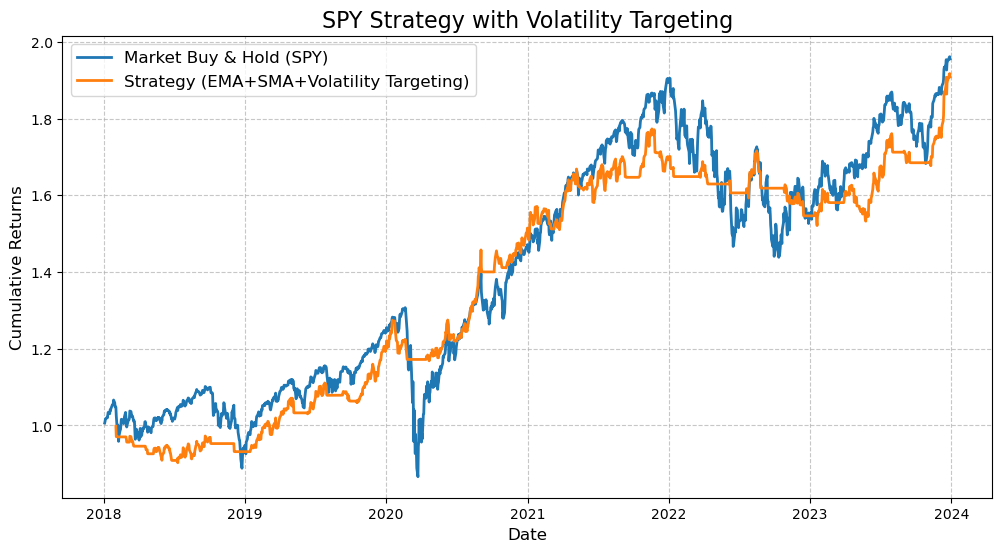

Strategy Sharpe Ratio: 1.10
Market Sharpe Ratio: 0.65
Final Strategy Return: 90.84%
Final Market Return: 95.54%


In [2]:
# Import libraries
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Parameters
symbol = 'SPY'
start_date = '2018-01-01'
end_date = '2024-01-01'
short_ema_window = 10
long_ema_window = 20
price_sma_window = 20
transaction_cost = 0.0005
volatility_lookback = 20  # days
target_volatility = 0.15  # Target annualized volatility (15%)

# Fetch data
data = yf.download(symbol, start=start_date, end=end_date)
data['Close_Price'] = data['Close']

# Indicators
data['Short_EMA'] = data['Close_Price'].ewm(span=short_ema_window, adjust=False).mean()
data['Long_EMA'] = data['Close_Price'].ewm(span=long_ema_window, adjust=False).mean()
data['Price_SMA'] = data['Close_Price'].rolling(window=price_sma_window).mean()

# Volatility estimation (rolling standard deviation of returns)
data['Daily_Return'] = data['Close_Price'].pct_change()
data['Realized_Vol'] = data['Daily_Return'].rolling(window=volatility_lookback).std() * np.sqrt(252)

# Signal generation
entry_condition = (data['Short_EMA'] > data['Long_EMA']) & (data['Close_Price'] > data['Price_SMA'])
exit_condition = data['Short_EMA'] < data['Long_EMA']

position = np.where(entry_condition, 1, 0)
position = np.where(exit_condition, 0, position)
data['Signal_Position'] = pd.Series(position, index=data.index).shift(1)

# Dynamic position sizing based on volatility targeting
# scale = target volatility / realized volatility
# cap scaling at 2x max to avoid extreme exposure
data['Scaling_Factor'] = target_volatility / data['Realized_Vol']
data['Scaling_Factor'] = data['Scaling_Factor'].clip(upper=2.0)

# Final dynamic position
data['Position'] = data['Signal_Position'] * data['Scaling_Factor']

# Returns
data['Strategy_Returns'] = data['Daily_Return'] * data['Position']

# Transaction costs
trade_signals = data['Position'].diff().abs()
data['Strategy_Returns_TC'] = data['Strategy_Returns'] - trade_signals * transaction_cost

# Cumulative returns
data['Market_Cumulative'] = (1 + data['Daily_Return']).cumprod()
data['Strategy_Cumulative'] = (1 + data['Strategy_Returns_TC']).cumprod()

# Sharpe ratio function
def sharpe_ratio(returns, risk_free_rate=0.0):
    excess_returns = returns - risk_free_rate / 252
    return np.sqrt(252) * excess_returns.mean() / returns.std()

# Performance evaluation
strategy_sharpe = sharpe_ratio(data['Strategy_Returns_TC'].dropna())
market_sharpe = sharpe_ratio(data['Daily_Return'].dropna())

# Plotting
plt.figure(figsize=(12,6))
plt.plot(data['Market_Cumulative'], label='Market Buy & Hold (SPY)', linewidth=2)
plt.plot(data['Strategy_Cumulative'], label='Strategy (EMA+SMA+Volatility Targeting)', linewidth=2)
plt.title(f"{symbol} Strategy with Volatility Targeting", fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Cumulative Returns', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Results
print(f"Strategy Sharpe Ratio: {strategy_sharpe:.2f}")
print(f"Market Sharpe Ratio: {market_sharpe:.2f}")
print(f"Final Strategy Return: {data['Strategy_Cumulative'].iloc[-1] - 1:.2%}")
print(f"Final Market Return: {data['Market_Cumulative'].iloc[-1] - 1:.2%}")